XOR Predictions

[0 0] Actual: 0 Predicted: 0
[0 1] Actual: 1 Predicted: 1
[1 0] Actual: 1 Predicted: 1
[1 1] Actual: 0 Predicted: 0

Accuracy: 100.0 %

Hidden Layer Weights:
[[ 3.2323288   5.47473   ]
 [-3.51047757 -4.42005663]]

Output Layer Weights:
[[-5.65510552]
 [ 5.45564502]]

Hidden Bias:
[ 1.93246072 -3.09300801]

Output Bias:
[5.2426612]


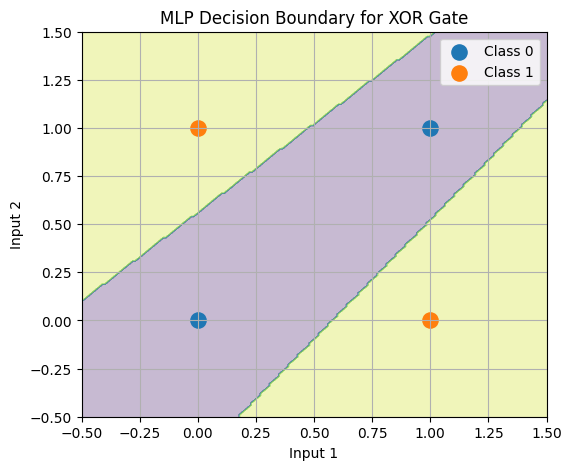

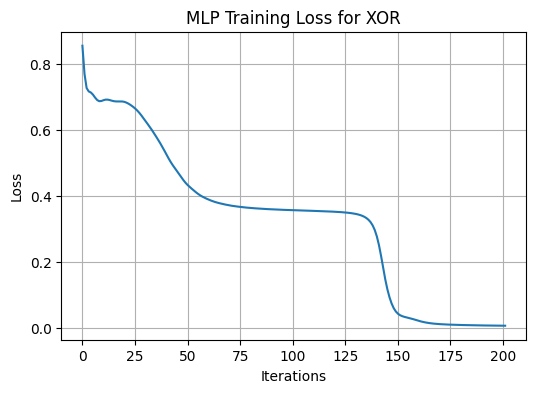


MLP plots zipped successfully!
File created: MLP_XOR_Plots.zip


In [1]:
# ============================================================
# MULTI LAYER PERCEPTRON (MLP) FOR XOR GATE
#
# Architecture:
# Input Layer (2 neurons)
# Hidden Layer (2 neurons)
# Output Layer (1 neuron)
#
# Uses sklearn MLPClassifier
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score



# ------------------------------------------------------------
# XOR Dataset
# ------------------------------------------------------------

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])


y = np.array([
    0,
    1,
    1,
    0
])



# ------------------------------------------------------------
# Create MLP Model
# ------------------------------------------------------------

mlp = MLPClassifier(

    hidden_layer_sizes=(2,),   # 2 neurons in hidden layer

    activation='tanh',

    solver='adam',

    learning_rate_init=0.1,

    max_iter=1000,

    random_state=42
)



# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

mlp.fit(
    X,
    y
)



# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

predictions = mlp.predict(X)


print("XOR Predictions\n")


for i in range(len(X)):

    print(
        X[i],
        "Actual:",
        y[i],
        "Predicted:",
        predictions[i]
    )



# Accuracy

accuracy = accuracy_score(
    y,
    predictions
)


print("\nAccuracy:",
      accuracy*100,
      "%")



# ------------------------------------------------------------
# Display Learned Weights
# ------------------------------------------------------------

print("\nHidden Layer Weights:")
print(mlp.coefs_[0])


print("\nOutput Layer Weights:")
print(mlp.coefs_[1])


print("\nHidden Bias:")
print(mlp.intercepts_[0])


print("\nOutput Bias:")
print(mlp.intercepts_[1])





# ------------------------------------------------------------
# Decision Boundary Plot
# ------------------------------------------------------------

os.makedirs(
    "MLP_Plots",
    exist_ok=True
)



xx,yy = np.meshgrid(
    np.linspace(-0.5,1.5,200),
    np.linspace(-0.5,1.5,200)
)



grid = np.c_[

    xx.ravel(),

    yy.ravel()

]



Z = mlp.predict(grid)


Z = Z.reshape(
    xx.shape
)



plt.figure(figsize=(6,5))


plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)



for label in np.unique(y):

    plt.scatter(

        X[y==label,0],

        X[y==label,1],

        s=120,

        label=f"Class {label}"

    )



plt.xlabel("Input 1")

plt.ylabel("Input 2")


plt.title(
    "MLP Decision Boundary for XOR Gate"
)


plt.grid()

plt.legend()



plt.savefig(

    "MLP_Plots/XOR_MLP_boundary.png",

    dpi=300,

    bbox_inches="tight"

)


plt.show()





# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(6,4))


plt.plot(
    mlp.loss_curve_
)


plt.xlabel(
    "Iterations"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "MLP Training Loss for XOR"
)


plt.grid()



plt.savefig(

    "MLP_Plots/MLP_training_loss.png",

    dpi=300,

    bbox_inches="tight"

)


plt.show()





# ------------------------------------------------------------
# Create ZIP File
# ------------------------------------------------------------

shutil.make_archive(

    "MLP_XOR_Plots",

    "zip",

    "MLP_Plots"

)


print(
    "\nMLP plots zipped successfully!"
)

print(
    "File created: MLP_XOR_Plots.zip"
)